0 - Bibliotecas e carga de dados

In [1]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)


# Carregando arquivos Parquet

DADOS_DIR = Path("../dados/consolidados")

#print(DADOS_DIR.resolve())
#print(list(DADOS_DIR.iterdir()))

mshl = pd.read_parquet(DADOS_DIR / "MSHL_consolidado.parquet")
cnes_lt = pd.read_parquet(DADOS_DIR / "LT_consolidado.parquet")
sih_rd = pd.read_parquet(DADOS_DIR / "RD_consolidado.parquet")

#Verificar se carregou corretamente
print("MSHL:", mshl.shape)
print("CNES-LT:", cnes_lt.shape)
print("SIH-RD:", sih_rd.shape)

MSHL: (2673, 9)
CNES-LT: (13079, 8)
SIH-RD: (696841, 20)


Quantas internações acontecem por leito disponível?

In [6]:
#Criar tabela mensal de leitos
leitos_mes = (
    cnes_lt.groupby(["COMPETEN", "CNES"])
    .agg(
        leitos_sus=("QT_SUS", "sum")
    )
    .reset_index()
)

#Criar competência das internações
sih_rd["COMPETENCIA"] = (
    sih_rd["DT_INTER"]
    .dt.strftime("%Y%m")
)
sih_rd["COMPETENCIA"] = sih_rd["COMPETENCIA"].astype(str)
cnes_lt["COMPETEN"] = cnes_lt["COMPETEN"].astype(str)

#Internações por unidade/mês
internacoes_mes_cnes = (
    sih_rd.groupby(["COMPETENCIA", "CNES"])
    .agg(
        internacoes=("N_AIH", "nunique"),
        dias_permanencia=("DIAS_PERM", "sum")
    )
    .reset_index()
)

# Cruzar leitos e internações
leitos_internacoes = leitos_mes.merge(
    internacoes_mes_cnes,
    left_on=["COMPETEN", "CNES"],
    right_on=["COMPETENCIA", "CNES"],
    how="left"
)

leitos_internacoes[
    ["internacoes", "dias_permanencia"]
] = leitos_internacoes[
    ["internacoes", "dias_permanencia"]
].fillna(0)

Indicador de utilização do leito

In [8]:
leitos_internacoes["dias_leito_disponiveis"] = (
    leitos_internacoes["leitos_sus"] * 30
)

leitos_internacoes["taxa_ocupacao_aprox"] = (
    leitos_internacoes["dias_permanencia"]
    / leitos_internacoes["dias_leito_disponiveis"]
)

leitos_internacoes["taxa_ocupacao_aprox"] *= 100

Internações por leito

In [9]:
leitos_internacoes["internacoes_por_leito"] = (
    leitos_internacoes["internacoes"]
    / leitos_internacoes["leitos_sus"]
)

leitos_internacoes[
    [
        "COMPETEN",
        "CNES",
        "leitos_sus",
        "internacoes",
        "internacoes_por_leito",
        "taxa_ocupacao_aprox"
    ]
].sort_values(
    "internacoes_por_leito",
    ascending=False
).head(30)

,COMPETEN,CNES,leitos_sus,internacoes,internacoes_por_leito,taxa_ocupacao_aprox
2497,202606,8097283,1,245.00,245.00,"3,926.67"
2413,202605,8097283,1,243.00,243.00,"3,470.00"
2329,202604,8097283,1,176.00,176.00,"3,623.33"
1347,202505,0000701,3,433.00,144.33,"1,167.78"
262,202404,0000701,3,382.00,127.33,"1,374.44"
1431,202506,0000701,3,370.00,123.33,"1,056.67"
346,202405,0000701,3,360.00,120.00,"1,333.33"
10,202401,0000701,3,354.00,118.00,"1,215.56"
2180,202603,0000701,3,343.00,114.33,"1,047.78"
94,202402,0000701,3,339.00,113.00,"1,314.44"


Tempo de permanência e utilização da capacidade

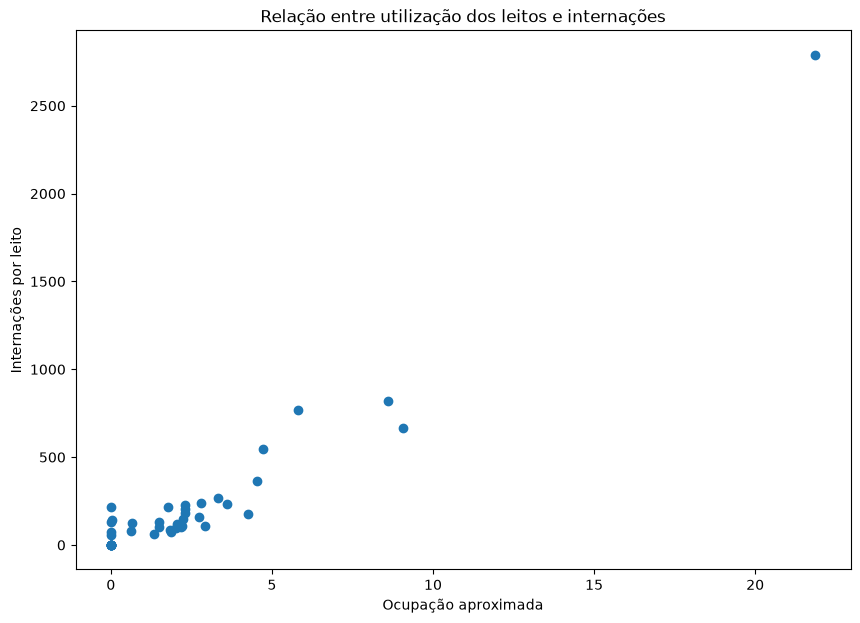

In [11]:
indicadores_cnes = (
    leitos_internacoes.groupby("CNES")
    .agg(
        leitos_medio=("leitos_sus", "mean"),
        internacoes=("internacoes", "sum"),
        dias_permanencia=("dias_permanencia", "sum")
    )
    .reset_index()
)

indicadores_cnes["internacoes_por_leito"] = (
    indicadores_cnes["internacoes"]
    / indicadores_cnes["leitos_medio"]
)

indicadores_cnes["dias_leito_disponiveis"] = (
    indicadores_cnes["leitos_medio"] * 365
)

indicadores_cnes["ocupacao_aproximada"] = (
    indicadores_cnes["dias_permanencia"]
    / indicadores_cnes["dias_leito_disponiveis"]
)

plt.figure(figsize=(10, 7))

plt.scatter(
    indicadores_cnes["ocupacao_aproximada"],
    indicadores_cnes["internacoes_por_leito"]
)

plt.xlabel("Ocupação aproximada")
plt.ylabel("Internações por leito")
plt.title("Relação entre utilização dos leitos e internações")

plt.show()